In [ ]:
### Exercise 2: Generate 2D data with meshgrid and plot two line slices
###
### Task:
### Generate a 2D function:
###
###     z = sin(pi * x) * cos(pi * y)
###
### where:
###
###     x ranges from -1 to 1
###     y ranges from 0 to 2
###
### Then plot two line slices on the same figure:
###
###     1. z values when x = 0, with y varying from 0 to 2
###     2. z values when x = 1, with y varying from 0 to 2
### using Numpy and Matplotlib.

### Important requirement:
### Choose equally spaced points for x such that x = 0 and x = 1
### are exactly included in the generated x array.
###
### Requirements:
### 1. Generate equally spaced x values from -1 to 1.
### 2. Generate equally spaced y values from 0 to 2.
### 3. Make sure x = 0 and x = 1 are exactly included in x.
### 4. Use np.meshgrid() to create 2D coordinate arrays.
### 5. Compute Z = sin(pi * X) * cos(pi * Y).
### 6. Extract the slice where x = 0 exactly.
### 7. Extract the slice where x = 1 exactly.
### 8. Plot both slices against y using plt.plot().
### 9. Use different colors, line styles, labels, and linewidths.
### 10. Add x-axis label, y-axis label, title, legend, and grid.
### 11. Save the figure to your computer with file name 'practice2.png'



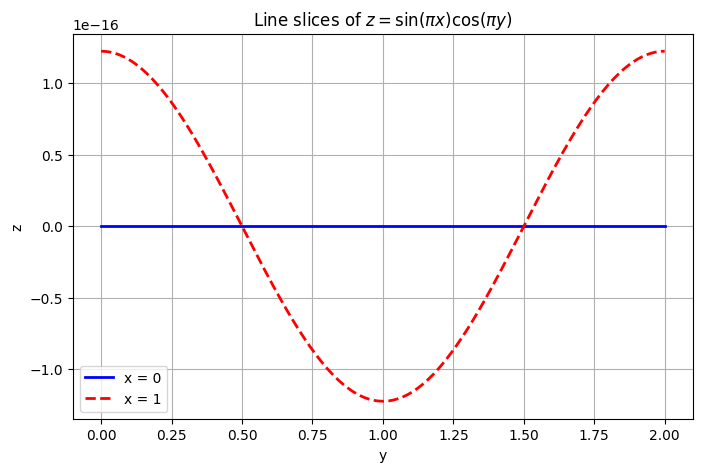

In [4]:
import numpy as np
import matplotlib.pyplot as plt


x = np.linspace(-1, 1, 201)
y = np.linspace(0, 2, 201)
X, Y = np.meshgrid(x, y)

Z = np.sin(np.pi * X) * np.cos(np.pi * Y)

idx_x0 = np.argmin(np.abs(x - 0))
idx_x1 = np.argmin(np.abs(x - 1))

z_slice_x0 = Z[:, idx_x0]
z_slice_x1 = Z[:, idx_x1]

plt.figure(figsize=(8, 5))
plt.plot(y, z_slice_x0, color='blue', linestyle='-', linewidth=2, label='x = 0')
plt.plot(y, z_slice_x1, color='red', linestyle='--', linewidth=2, label='x = 1')
plt.xlabel('y')
plt.ylabel('z')

plt.title(r'Line slices of $z = \sin(\pi x) \cos(\pi y)$')
plt.legend()
plt.grid(True)

plt.savefig('practice2.png', dpi=150)
plt.show()

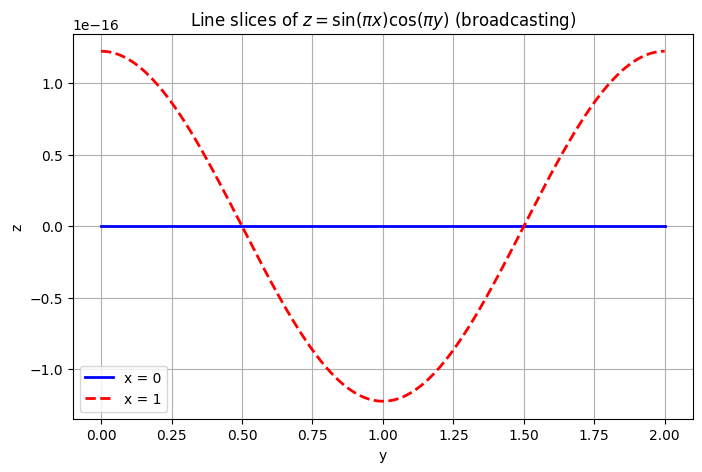

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 修改范围：按题目要求使用 -1 到 1，以及 0 到 2
# 这样不仅符合要求，而且 201 个点能保证 0 和 1 刚好落在数组里
x = np.linspace(-1, 1, 201)
y = np.linspace(0, 2, 201)

# 2. 广播机制计算 Z (这一步你写得很完美)
Z_bc = np.sin(np.pi * x) * np.cos(np.pi * y[:, np.newaxis])

# 3. 提取切片
# 强烈推荐使用 np.isclose() 代替 'x == 1' 这种直接用 '==' 判断浮点数的写法
# 它可以完美规避计算机浮点数精度带来的微小误差 (比如 0.99999999999)
z_slice_x0_bc = Z_bc[:, np.isclose(x, 0)].ravel()
z_slice_x1_bc = Z_bc[:, np.isclose(x, 1)].ravel()

# 4. 绘图
plt.figure(figsize=(8, 5))
plt.plot(y, z_slice_x0_bc, color='blue', linestyle='-', linewidth=2, label='x = 0')
plt.plot(y, z_slice_x1_bc, color='red', linestyle='--', linewidth=2, label='x = 1')
plt.xlabel('y')
plt.ylabel('z')

# 修改：添加了 r 前缀防止 LaTeX 语法被识别为转义字符
plt.title(r'Line slices of $z = \sin(\pi x) \cos(\pi y)$ (broadcasting)')
plt.legend()
plt.grid(True)
plt.savefig('practice2.png', dpi=150)
plt.show()